In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
import json

# loading the dataset

drebin_df = pd.read_csv("shuffled_apk_dataset.csv", low_memory = False)




In [41]:
drebin_df.head(20)
print("Shape:", drebin_df.shape)

Shape: (15036, 216)


In [14]:
X = drebin_df.drop(columns=['class'])
label_map = {'B': 0, 'S': 1}
y = drebin_df['class'].map(label_map)

In [15]:
# Maping  'B' -> 0 (benign), 'S' -> 1 (malware)

y.head(20)


0     0
1     0
2     0
3     1
4     0
5     0
6     0
7     0
8     0
9     0
10    1
11    1
12    0
13    1
14    1
15    1
16    0
17    0
18    1
19    0
Name: class, dtype: int64

In [42]:
# Detect rows with non-numeric values in the column
bad_rows = X[~X['TelephonyManager.getSimCountryIso'].apply(lambda x: str(x).isdigit())]

# Display them
print("⚠️ Non-numeric rows:")
print(bad_rows)

# Optional: Show indices
print("Row indices with non-numeric values:", bad_rows.index.tolist())


⚠️ Non-numeric rows:
Empty DataFrame
Columns: [transact, onServiceConnected, bindService, attachInterface, ServiceConnection, android.os.Binder, SEND_SMS, Ljava.lang.Class.getCanonicalName, Ljava.lang.Class.getMethods, Ljava.lang.Class.cast, Ljava.net.URLDecoder, android.content.pm.Signature, android.telephony.SmsManager, READ_PHONE_STATE, getBinder, ClassLoader, Landroid.content.Context.registerReceiver, Ljava.lang.Class.getField, Landroid.content.Context.unregisterReceiver, GET_ACCOUNTS, RECEIVE_SMS, Ljava.lang.Class.getDeclaredField, READ_SMS, getCallingUid, Ljavax.crypto.spec.SecretKeySpec, android.intent.action.BOOT_COMPLETED, USE_CREDENTIALS, MANAGE_ACCOUNTS, android.content.pm.PackageInfo, KeySpec, TelephonyManager.getLine1Number, DexClassLoader, HttpGet.init, SecretKey, Ljava.lang.Class.getMethod, System.loadLibrary, android.intent.action.SEND, Ljavax.crypto.Cipher, WRITE_SMS, READ_SYNC_SETTINGS, AUTHENTICATE_ACCOUNTS, android.telephony.gsm.SmsManager, WRITE_HISTORY_BOOKMARKS, 

In [43]:
# Convert all columns in X to integer type
X = X.astype(int)

# Confirm data types
print(X.dtypes.value_counts())


int64    215
Name: count, dtype: int64


In [44]:
X = X.fillna(0).astype(int)

In [45]:
# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
# Feature Importance (Option A - Mutual Information)
mi_scores = mutual_info_classif(X_train, y_train, discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns)
top_features_mi = mi_series.sort_values(ascending=False).head(100)


In [47]:
# Feature Importance (Option B - Random Forest) ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features_rf = rf_importances.sort_values(ascending=False).head(100)

In [48]:
# Saving Top Features ---
top_features = list(set(top_features_mi.index).union(set(top_features_rf.index)))
print(f"Selected top {len(top_features)} features from Drebin.")

Selected top 123 features from Drebin.


In [49]:
with open("drebin_top_features.json", "w") as f:
    json.dump(top_features, f)

<Axes: title={'center': 'Top MI Features'}>

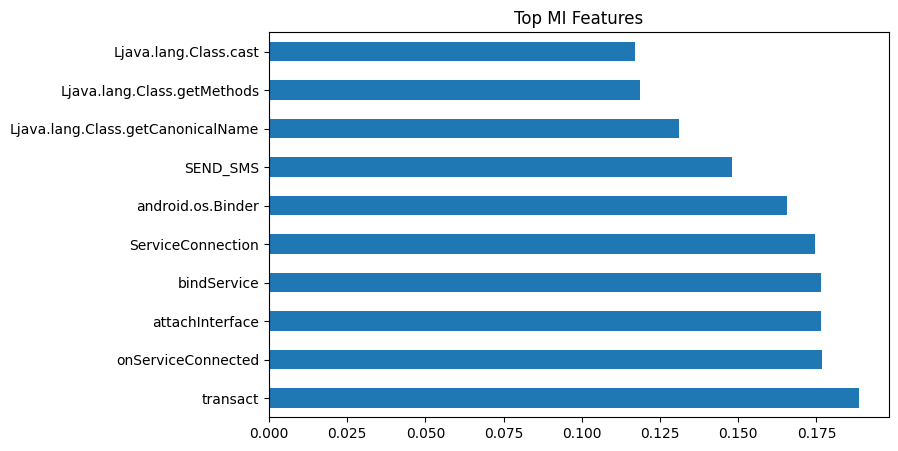

In [50]:
top_features_mi.head(10).plot(kind='barh', title="Top MI Features", figsize=(8, 5))

<Axes: title={'center': 'Top RF Features'}>

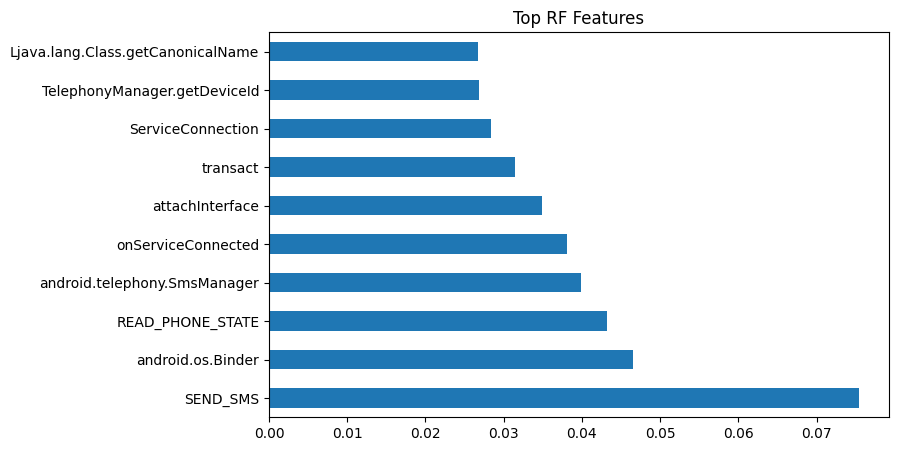

In [52]:
top_features_rf.head(10).plot(kind='barh', title="Top RF Features", figsize=(8, 5))